# Type III Burst Detection — Full Year 2003

This notebook processes every `.roh` file in the 2003 OSRA archive directory  
`/net/lyot/scratch3/vocks/OSRA/2003/`  
and runs the same daytime-masked Type III detection pipeline used in  
`wholeday_bursts_daymask.ipynb`, but looped automatically over all observation days.

**Pipeline summary (per file)**
1. Read f2-band spectrogram via `drb.read_osraf2()`
2. Compute sunrise / sunset for Tremsdorf observatory
3. Apply daytime mask (detection runs on daylight samples only)
4. For each of 24 hours: preprocess → binarize → Hough detect → group lines → count confirmed bursts
5. Append one row to the yearly CSV via `drb.append_daily_csv()`

**Output**
- Yearly CSV: `outputs/solar_cycle/bursts_2003.csv`
- Summary bar chart of daily total confirmed bursts across 2003

## 1  Imports

In [1]:
import sys
sys.path.insert(1, '/work1/okoro/type3detectosra/')  # path to DetectRadioburst_OSRA and RadioTools

import os
import glob
import datetime
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import scipy.ndimage

# Astropy tools for sunrise/sunset computation at Tremsdorf
from astropy.time import Time
from astropy.coordinates import EarthLocation, get_sun, AltAz
import astropy.units as u

# Project-specific detection module (must be on sys.path above)
import DetectRadioburst_OSRA as drb
from DetectRadioburst_OSRA import append_daily_csv

print("All imports successful.")

All imports successful.


## 2  Configuration

In [2]:
#  Top-level OSRA 2003 archive directory --------------------------------
# All CD_NNN subdirectories inside this path will be scanned for .roh files.
OSRA_2003_DIR = "/net/lyot/scratch3/vocks/OSRA/2003/"

#  Output directory for the yearly CSV --------------------------------
# append_daily_csv() will create this directory automatically if needed.
OUTPUT_DIR = "outputs_Oneyear/solar_cycle"

#  Tremsdorf Radio Observatory coordinates --------------------------------
# Used to compute sunrise and sunset times so the daytime mask can be applied.
# Coordinates: 52.2167° N, 13.1833° E, 65 m altitude
TREMSDORF = EarthLocation(
    lat=52.2167 * u.deg,
    lon=13.1833 * u.deg,
    height=65 * u.m
)

# Hough detection parameters ----------------------------------------
# These mirror the settings used in wholeday_bursts_daymask.ipynb.
HOUGH_THRESHOLD   = 30    # minimum pixel votes for a Hough line to be accepted
HOUGH_LINE_GAP    = 10    # maximum gap (pixels) allowed within one line segment
HOUGH_LINE_LENGTH = 50    # minimum span (pixels) a line must cover

# Angle range: near-vertical lines only (Type III bursts drift near-vertically
# in time–frequency space at these frequency resolutions)
HOUGH_THETA = np.linspace(
    np.pi/2 - np.pi/8,          # start: ~67.5°
    np.pi/2 - 0.5/180*np.pi,    # end  : ~89.7°
    300
)

#  Binarization parameters ───────────────────────────────────────────────────
BINAR_N_ORDER = 8      # how many neighbours on each side to compare
BINAR_PEAK_R  = 0.9993 # tolerance: neighbours must be < peak_r * pixel_value

#  Pre-processing Gaussian smoothing ............................................
# (sigma_time, sigma_freq) — smoothing along time axis only, as in the notebook
GAUSS_SIGMA = (5.5, 0.0)

#  Line grouping distance threshold .........................................
# Two Hough lines closer than this (pixels, perpendicular) belong to one burst.
LINE_GROUP_MIN_DIST = 10

print(f"OSRA 2003 directory : {OSRA_2003_DIR}")
print(f"Output directory    : {OUTPUT_DIR}")

OSRA 2003 directory : /net/lyot/scratch3/vocks/OSRA/2003/
Output directory    : outputs_Oneyear/solar_cycle


## 3  Discover all `.roh` files for 2003

Walk every `CD_NNN` subdirectory and collect `.roh` file paths,  
sorted chronologically by filename.

In [3]:
# Recursively glob for every .roh file under the 2003 root directory.
# Sorting by filename gives approximate chronological order because the
# OSRA naming convention encodes the date: YYMMDD_CCC.roh
roh_files = sorted(glob.glob(os.path.join(OSRA_2003_DIR, "**", "*.roh"), recursive=True))

print(f"Found {len(roh_files)} .roh files in 2003 archive.")
print("\nFirst 5:")
for f in roh_files[:5]:
    print(" ", f)
print("...")
print("Last 5:")
for f in roh_files[-5:]:
    print(" ", f)

Found 158 .roh files in 2003 archive.

First 5:
  /net/lyot/scratch3/vocks/OSRA/2003/CD_001/030101_001.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_002/030102_002.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_004/030104_004.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_005/030105_005.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_007/030107_007.roh
...
Last 5:
  /net/lyot/scratch3/vocks/OSRA/2003/CD_361/031227_361.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_362/031228_362.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_363/031229_363.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_364/031230_364.roh
  /net/lyot/scratch3/vocks/OSRA/2003/CD_365/031231_365.roh


## 4  Helper — Sunrise / Sunset for Tremsdorf

Identical to the function in `wholeday_bursts_daymask.ipynb`.  
Uses sparse sampling (~100 points) for speed; the solar-altitude  
zero-crossing gives sunrise and sunset to within a few minutes.

In [4]:
def compute_sunrise_sunset(t_fits, location=TREMSDORF, step=None):
    """
    Return sunrise and sunset times from the observation time array.

    Uses sparse sampling (~100 points) to locate the solar-altitude
    zero-crossing efficiently, with a standard refraction correction
    of +0.833 degrees applied to the solar altitude.

    Parameters
    ----------
    t_fits   : 1D array of Python datetime objects for the full observation day
    location : EarthLocation  — observatory position (default: Tremsdorf)
    step     : int or None    — sampling stride; None → auto (len // 100)

    Returns
    -------
    sunrise_str : str           "HH:MM" UT  or  "NO_RISE"
    sunset_str  : str           "HH:MM" UT  or  "NO_SET"
    sunrise_dt  : datetime      Python datetime of the zero-crossing
    sunset_dt   : datetime      Python datetime of the zero-crossing
    """
    if step is None:
        step = max(1, len(t_fits) // 100)
    t_sparse = t_fits[::step]

    times       = Time(list(t_sparse))
    altaz_frame = AltAz(obstime=times, location=location)
    sun_altaz   = get_sun(times).transform_to(altaz_frame)
    altitudes   = sun_altaz.alt.deg + 0.833   # standard atmospheric refraction

    # Locate the negative → positive crossing (sunrise)
    sunrise_idx = np.where((altitudes[:-1] < 0) & (altitudes[1:] >= 0))[0]
    # Locate the positive → negative crossing (sunset)
    sunset_idx  = np.where((altitudes[:-1] >= 0) & (altitudes[1:] < 0))[0]

    if len(sunrise_idx) > 0:
        sunrise_dt  = t_sparse[sunrise_idx[0]]
        sunrise_str = sunrise_dt.strftime("%H:%M")
    else:
        # Sun never rises on this day (polar night or data gap) — use file start
        sunrise_dt  = t_fits[0]
        sunrise_str = "NO_RISE"

    if len(sunset_idx) > 0:
        sunset_dt  = t_sparse[sunset_idx[0]]
        sunset_str = sunset_dt.strftime("%H:%M")
    else:
        # Sun never sets (midnight sun) — use file end
        sunset_dt  = t_fits[-1]
        sunset_str = "NO_SET"

    return sunrise_str, sunset_str, sunrise_dt, sunset_dt


print("compute_sunrise_sunset() defined.")

compute_sunrise_sunset() defined.


## 5  Helper — Process one `.roh` file (full detection pipeline)
4 hou
Encapsulates the complete per-day pipeline from `wholeday_bursts_daymask.ipynb`  
so the main loop in Section 6 stays readable.  

Returns a list of 2rly result dicts (one per UTC hour),  
identical in format to what `append_daily_csv()` expects.

In [5]:
def process_one_file(fname):
    """
    Run the full Type III detection pipeline on one OSRA .roh file.

    Steps
    -----
    1. Read the f2-band spectrogram (400–200 MHz, 256 channels)
    2. Compute sunrise / sunset for Tremsdorf
    3. Apply the daytime mask — detection operates on daylight samples only
    4. Loop through all 24 UTC hours:
         a. Skip if no daytime samples in this hour
         b. Preprocess (background removal + Gaussian smoothing)
         c. Binarize (local time-axis peak detection)
         d. Probabilistic Hough line detection
         e. Group nearby Hough lines into burst candidates
         f. Count confirmed bursts (groups with more than 1 Hough line)
    5. Return the 24-entry results list

    Parameters
    ----------
    fname : str  — full path to the .roh file

    Returns
    -------
    hourly_results : list of 24 dicts
        Each dict contains: hour, bursts, raw_groups, samples,
                            daylight, sunrise_ut, sunset_ut
    t_fits : 1D array of Python datetime objects (full day)
    """

    # ── Step 1: Read the .roh file (f2 band only, 400–200 MHz) ───────────────
    # read_osraf2 extracts bytes 272–527 of each 1040-byte record, which
    # correspond to the f2 antenna (256 channels, 400 → 200 MHz).
    dyspec, t_fits, f_fits = drb.read_osraf2(fname)

    # Ensure all timestamps are plain Python datetime objects.
    # (read_osraf2 already calls to_python_datetime, but this guards
    #  against any edge cases with the numpy datetime64 wrapper)
    t_fits = drb.to_python_datetime(t_fits)
    t_fits = np.array(t_fits).astype('datetime64[ms]').astype(datetime.datetime)

    # ── Step 2: Compute sunrise / sunset at Tremsdorf ─────────────────────────
    # Sparse sampling makes this fast: ~100 solar-altitude evaluations
    # instead of one per record.
    sunrise_str, sunset_str, sunrise_dt, sunset_dt = compute_sunrise_sunset(t_fits)

    # ── Step 3: Apply the daytime mask ────────────────────────────────────────
    # The boolean mask selects only the records that fall between sunrise
    # and sunset. Detection is run exclusively on these daytime samples.
    # Night hours will be written as zero rows in the output — this ensures
    # the 24-hour DataFrame / CSV structure is always complete.
    time_mask_day = (t_fits >= sunrise_dt) & (t_fits <= sunset_dt)
    day_t_fits    = t_fits[time_mask_day]
    day_dyspec    = dyspec[time_mask_day, :]

    # ── Step 4: Hour loop — 00:00 to 23:00 UTC ───────────────────────────────
    # All 24 hours are iterated. For daytime hours with data the full
    # detection chain runs. For night hours (no samples in day_t_fits)
    # a zero row is appended directly so the list is always length 24.

    hourly_results = []  # CRITICAL: initialised outside the loop

    # Midnight of the observation day — used as the origin for hour slicing
    base_date = t_fits[0].replace(hour=0, minute=0, second=0, microsecond=0)

    for h in range(24):
        start_time = base_date + datetime.timedelta(hours=h)
        end_time   = start_time + datetime.timedelta(hours=1)

        # Classify the hour as DAY or NIGHT based on its midpoint
        hour_midpoint = start_time + datetime.timedelta(minutes=30)
        daylight_flag = "DAY" if (sunrise_dt <= hour_midpoint <= sunset_dt) else "NIGHT"

        # Hour mask applied to the DAYTIME-ONLY arrays.
        # Night hours find zero matching indices here and are recorded as zeros.
        time_mask = (day_t_fits >= start_time) & (day_t_fits < end_time)
        idx       = np.where(time_mask)[0]

        # ── CASE 1: no daytime data in this hour (night or data gap) ─────────
        if len(idx) == 0:
            hourly_results.append({
                "hour"       : h,
                "bursts"     : 0,
                "raw_groups" : 0,
                "samples"    : 0,
                "daylight"   : daylight_flag,
                "sunrise_ut" : sunrise_str,
                "sunset_ut"  : sunset_str,
            })
            continue

        # Extract the daytime slice for this hour
        data_cut = day_dyspec[idx, :]
        t_cut    = day_t_fits[idx]

        # ── Step 4b: Preprocess — background removal + Gaussian smoothing ────
        # preproc2 divides each frequency channel by its quiet-time background
        # (10th–30th percentile in time), yielding burst excess ≈ positive,
        # then applies a Gaussian blur along the time axis only.
        data_fits_new, data_fits_new_smooth = drb.preproc2(
            data_cut, gauss_sigma=GAUSS_SIGMA
        )

        # ── CASE 2: blank spectrum after preprocessing ────────────────────────
        if np.all(data_fits_new_smooth == 0):
            hourly_results.append({
                "hour"       : h,
                "bursts"     : 0,
                "raw_groups" : 0,
                "samples"    : len(idx),
                "daylight"   : daylight_flag,
                "sunrise_ut" : sunrise_str,
                "sunset_ut"  : sunset_str,
            })
            continue

        # ── Step 4c: Binarization .........................................
        # Mark local time-axis peaks in the smoothed spectrum.
        # Only pixels strictly greater than all N_order neighbours on both
        # sides (within tolerance peak_r) survive as candidate burst pixels.
        bmap = drb.binarization(data_fits_new_smooth,
                                N_order=BINAR_N_ORDER,
                                peak_r=BINAR_PEAK_R)

        # ── Step 4d: Probabilistic Hough line detection ...................
        # Finds near-vertical line features in the binary map.
        # rng=42 inside hough_detect seeds the skimage internal RNG for
        # reproducibility (np.random.seed has no effect in skimage >= 0.19).
        lines = drb.hough_detect(
            bmap, data_cut,
            threshold=HOUGH_THRESHOLD,
            line_gap=HOUGH_LINE_GAP,
            line_length=HOUGH_LINE_LENGTH,
            theta=HOUGH_THETA
        )

        # ── CASE 3: no Hough lines found ..........................
        if len(lines) == 0:
            hourly_results.append({
                "hour"       : h,
                "bursts"     : 0,
                "raw_groups" : 0,
                "samples"    : len(idx),
                "daylight"   : daylight_flag,
                "sunrise_ut" : sunrise_str,
                "sunset_ut"  : sunset_str,
            })
            continue

        # ── Step 4e: Group nearby Hough lines into burst candidates ───────────
        # Lines whose perpendicular distance is < LINE_GROUP_MIN_DIST pixels
        # are merged into one group. Each group represents one potential burst.
        line_sets = drb.line_grouping(lines, min_dist=LINE_GROUP_MIN_DIST)

        # ── CASE 4: lines found but no groups formed ──────────────────────────
        if len(line_sets) == 0:
            hourly_results.append({
                "hour"       : h,
                "bursts"     : 0,
                "raw_groups" : 0,
                "samples"    : len(idx),
                "daylight"   : daylight_flag,
                "sunrise_ut" : sunrise_str,
                "sunset_ut"  : sunset_str,
            })
            continue

        # ── Step 4f: Count confirmed bursts ───────────────────────────────────
        # A group with more than 1 Hough line is a confirmed burst candidate.
        # Single-line groups are likely noise and are counted as raw_groups only.
        raw_groups = len(line_sets)
        confirmed  = sum(1 for ls in line_sets if len(ls) > 1)

        hourly_results.append({
            "hour"       : h,
            "bursts"     : confirmed,
            "raw_groups" : raw_groups,
            "samples"    : len(idx),
            "daylight"   : daylight_flag,
            "sunrise_ut" : sunrise_str,
            "sunset_ut"  : sunset_str,
        })

    # ── Safety assertion: every code path must have appended exactly one row ──
    assert len(hourly_results) == 24, (
        f"Expected 24 hourly records, got {len(hourly_results)}. "
        "Check that every branch of the hour loop calls hourly_results.append()."
    )

    return hourly_results, t_fits


print("process_one_file() defined.")

process_one_file() defined.


## 6  Main loop — process all 2003 files

For each `.roh` file discovered in Section 3:
- Run `process_one_file()` (the full detection pipeline)
- Append the daily result to `outputs/solar_cycle/bursts_2003.csv` via `append_daily_csv()`
- Collect summary statistics for the end-of-run chart

Files that fail (corrupt binary, incomplete reads, etc.) are logged to  
`failed_files` and processing continues with the next file.

In [6]:
# ── Accumulators for the end-of-run summary ───────────────────────────────────
# Each entry is one processed observation day.
summary_dates         = []   # date strings ("YYYY-MM-DD")
summary_total_bursts  = []   # total confirmed bursts for the day
summary_total_samples = []   # total daytime samples for the day

# ── Track files that could not be processed ───────────────────────────────────
failed_files = []

n_files = len(roh_files)
print(f"Starting detection run — {n_files} files to process.\n")
print("=" * 70)

for file_idx, fname in enumerate(roh_files):
    basename = os.path.basename(fname)
    print(f"\n[{file_idx + 1}/{n_files}]  {basename}")
    print("-" * 50)

    try:
        # ── Run the full detection pipeline for this file ─────────────────────
        hourly_results, t_fits = process_one_file(fname)

        # Extract the calendar date from the first timestamp in the file.
        # This is used as the row key in the yearly CSV.
        date_str = t_fits[0].strftime("%Y-%m-%d")

        # ── Append results to the yearly CSV ─────────────────────────────────
        # append_daily_csv writes one row per day to outputs/solar_cycle/bursts_2003.csv.
        # If the date already exists in the CSV the row is replaced (not duplicated),
        # so re-running this notebook is safe.
        append_daily_csv(
            hourly_results=hourly_results,
            date=date_str,
            output_dir=OUTPUT_DIR
        )

        # ── Accumulate summary statistics ──────────────────────────────────────
        total_bursts  = sum(r["bursts"]  for r in hourly_results)
        total_samples = sum(r["samples"] for r in hourly_results)

        summary_dates.append(date_str)
        summary_total_bursts.append(total_bursts)
        summary_total_samples.append(total_samples)

        print(f"  → {date_str} | confirmed bursts: {total_bursts} | "
              f"daytime samples: {total_samples}")

    except Exception as exc:
        # Log the failure and move on — one bad file should not abort the whole run.
        error_msg = traceback.format_exc()
        print(f"  ERROR processing {basename}: {exc}")
        print(error_msg)
        failed_files.append((fname, str(exc)))

print("\n" + "=" * 70)
print(f"Detection run complete.")
print(f"  Processed : {len(summary_dates)} files")
print(f"  Failed    : {len(failed_files)} files")
if failed_files:
    print("\nFailed files:")
    for fpath, err in failed_files:
        print(f"  {os.path.basename(fpath)} — {err}")

Starting detection run — 158 files to process.


[1/158]  030101_001.roh
--------------------------------------------------
  [2003-01-01] created → outputs_Oneyear/solar_cycle/bursts_2003.csv  (total bursts=4, raw_groups=7, samples=210608)
  → 2003-01-01 | confirmed bursts: 4 | daytime samples: 210608

[2/158]  030102_002.roh
--------------------------------------------------
  [2003-01-02] appended → outputs_Oneyear/solar_cycle/bursts_2003.csv  (total bursts=4, raw_groups=7, samples=210616)
  → 2003-01-02 | confirmed bursts: 4 | daytime samples: 210616

[3/158]  030104_004.roh
--------------------------------------------------
  [2003-01-04] appended → outputs_Oneyear/solar_cycle/bursts_2003.csv  (total bursts=15, raw_groups=55, samples=214222)
  → 2003-01-04 | confirmed bursts: 15 | daytime samples: 214222

[4/158]  030105_005.roh
--------------------------------------------------
  [2003-01-05] appended → outputs_Oneyear/solar_cycle/bursts_2003.csv  (total bursts=6, raw_groups=13, 

## 7  Load and inspect the yearly CSV

Read back the `bursts_2003.csv` file that was built incrementally above  
and display it as a DataFrame for a quick sanity check.

In [7]:
# ── Load the yearly CSV written by append_daily_csv() ─────────────────────────
yearly_csv_path = os.path.join(OUTPUT_DIR, "bursts_2003.csv")

df_2003 = pd.read_csv(yearly_csv_path, parse_dates=["date"])
df_2003 = df_2003.sort_values("date").reset_index(drop=True)

print(f"Loaded {len(df_2003)} daily rows from {yearly_csv_path}")
print(f"Date range: {df_2003['date'].min().date()}  →  {df_2003['date'].max().date()}")
print(f"Total confirmed bursts across 2003: {df_2003['total_bursts'].sum()}")
print()

# Display the summary columns only — the per-hour columns make the table very wide
display(
    df_2003[[
        "date", "total_bursts", "total_raw_groups", "total_samples"
    ]].to_string(index=False)
)

Loaded 156 daily rows from outputs_Oneyear/solar_cycle/bursts_2003.csv
Date range: 2003-01-01  →  2003-12-31
Total confirmed bursts across 2003: 32447



'      date  total_bursts  total_raw_groups  total_samples\n2003-01-01             4                 7         210608\n2003-01-02             4                 7         210616\n2003-01-04            15                55         214222\n2003-01-05             6                13         214236\n2003-01-07            11                56         217835\n2003-01-08             5                32         217814\n2003-01-16            13                27         226810\n2003-01-19             7                23         235808\n2003-01-20             2                 9         234013\n2003-01-21            13                38         239424\n2003-01-22             6                30         241206\n2003-01-23            11                46         246606\n2003-01-24             9                31         250203\n2003-01-25            17                60         253819\n2003-01-26            39               108         257434\n2003-01-27            11                51         2646

In [14]:
# ── Load the yearly CSV ──────────────────────────────────────────────────────
yearly_csv_path = os.path.join(OUTPUT_DIR, "bursts_2003.csv")

df_2003 = pd.read_csv(yearly_csv_path, parse_dates=["date"])
df_2003 = df_2003.sort_values("date").reset_index(drop=True)

print(f"Loaded {len(df_2003)} daily rows from {yearly_csv_path}")
print(f"Date range: {df_2003['date'].min().date()}  →  {df_2003['date'].max().date()}")
print(f"Total confirmed bursts across 2003: {df_2003['total_bursts'].sum()}")
print()

# Select summary columns
summary_df = df_2003[[
    "date",
    "total_bursts",
    "total_raw_groups",
    "total_samples"
]]

# Make dates cleaner
summary_df["date"] = summary_df["date"].dt.strftime("%Y-%m-%d")
summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "daily_typeIII_summary_2003.csv"),
    index=False
)

# Styled display
display(
    summary_df.style
    .hide(axis="index")  #.hide_index() option for modern pandas
    .set_caption("Daily Type III Burst Summary — 2003")
    .set_properties(**{
        "text-align": "center",
        "padding": "6px",
        "font-size": "12pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#222222"),
                ("color", "white"),
                ("font-size", "13pt"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16pt"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        }
    ])
    .background_gradient(
        subset=["total_bursts"],
        cmap="inferno"
    )
)

Loaded 156 daily rows from outputs_Oneyear/solar_cycle/bursts_2003.csv
Date range: 2003-01-01  →  2003-12-31
Total confirmed bursts across 2003: 32447



date,total_bursts,total_raw_groups,total_samples
2003-01-01,4,7,210608
2003-01-02,4,7,210616
2003-01-04,15,55,214222
2003-01-05,6,13,214236
2003-01-07,11,56,217835
2003-01-08,5,32,217814
2003-01-16,13,27,226810
2003-01-19,7,23,235808
2003-01-20,2,9,234013
2003-01-21,13,38,239424


## 8  Summary chart — daily confirmed bursts across 2003

Two-panel figure:
- **Top**: daily total confirmed burst count (bar chart)
- **Bottom**: daily total daytime samples (line chart)

The samples panel serves as a data-quality indicator: a day with  
very few samples (equipment off, cloudy RFI environment, file gaps)  
should not be interpreted as a quiet solar day.

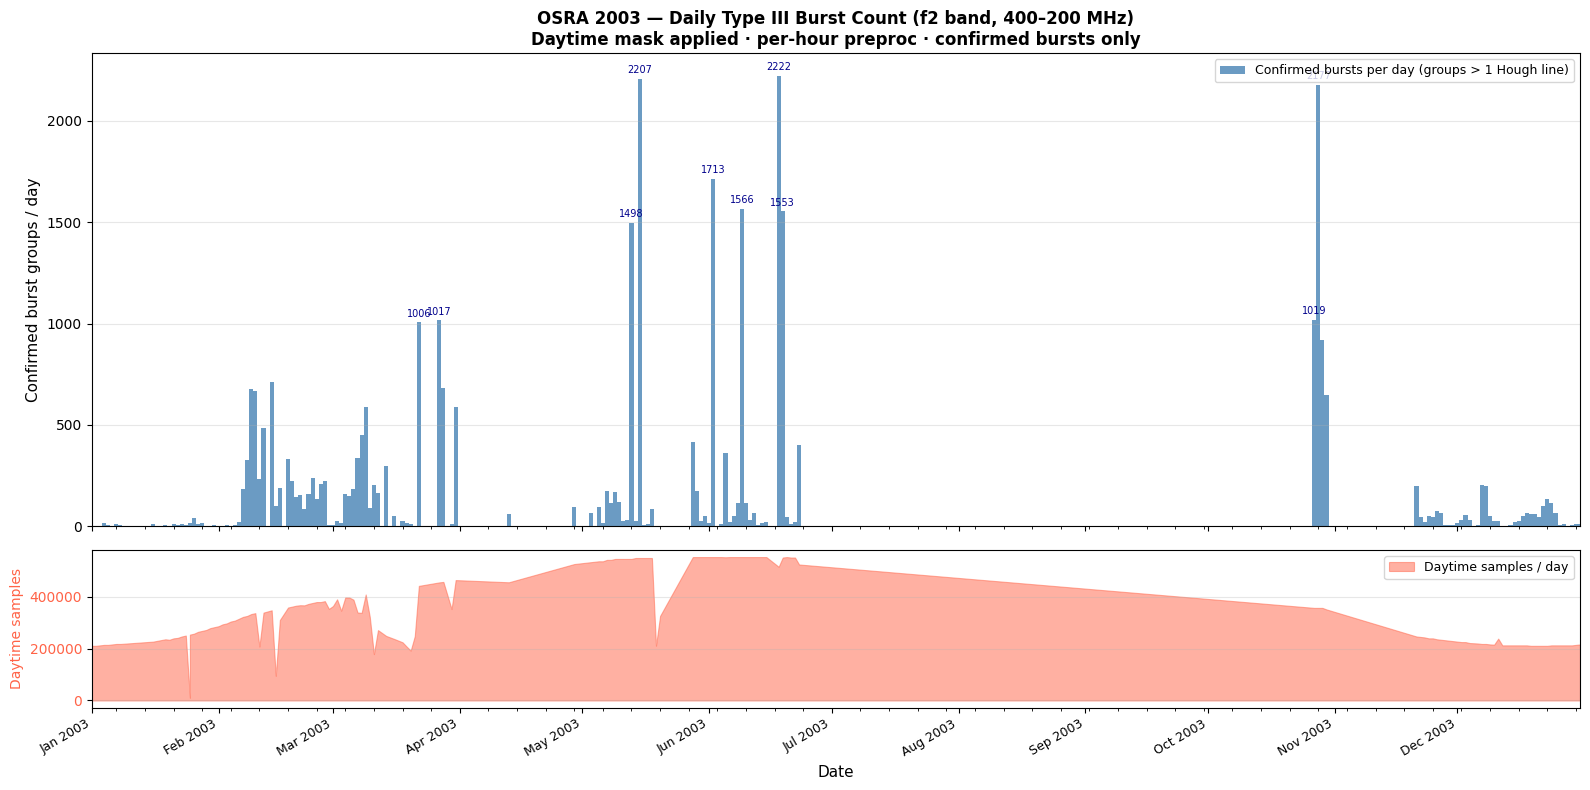


Total confirmed bursts detected in 2003: 32448
Days with at least one burst: 157 / 157
Peak day: 2003-06-18  (2222 bursts)


In [15]:
# Convert the summary accumulators to numpy arrays for plotting.
# (Use the in-memory accumulators rather than re-reading the CSV so that
# the chart updates even if the CSV has not been flushed to disk yet.)
plot_dates   = pd.to_datetime(summary_dates)
plot_bursts  = np.array(summary_total_bursts)
plot_samples = np.array(summary_total_samples)

# ── Figure: two stacked panels ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# ── Top panel: daily confirmed burst count ────────────────────────────────────
ax1.bar(
    plot_dates, plot_bursts,
    width=1.0,
    color='steelblue', alpha=0.8,
    label='Confirmed bursts per day (groups > 1 Hough line)'
)

# Highlight the top 10 burst days with text annotations for quick identification
top10_idx = np.argsort(plot_bursts)[-10:]
for i in top10_idx:
    if plot_bursts[i] > 0:
        ax1.annotate(
            f"{plot_bursts[i]}",
            xy=(plot_dates[i], plot_bursts[i]),
            xytext=(0, 4), textcoords='offset points',
            ha='center', fontsize=7, color='darkblue'
        )

ax1.set_ylabel('Confirmed burst groups / day', fontsize=11)
ax1.set_title(
    'OSRA 2003 — Daily Type III Burst Count (f2 band, 400–200 MHz)\n'
    'Daytime mask applied · per-hour preproc · confirmed bursts only',
    fontsize=12, fontweight='bold'
)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Bottom panel: daytime samples per day (data-quality indicator) ────────────
ax2.fill_between(
    plot_dates, plot_samples,
    color='tomato', alpha=0.5, linewidth=0.8,
    label='Daytime samples / day'
)
ax2.set_ylabel('Daytime samples', fontsize=10, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_minor_locator(mdates.WeekdayLocator())
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=9)

ax2.set_xlabel('Date', fontsize=11)
ax2.set_xlim(plot_dates[0], plot_dates[-1])

plt.tight_layout()
plt.savefig(
    "/work1/okoro/type3detectosra/type3detectosra/outputs_Oneyear/solar_cycle/'OSRA 2003 — Daily Type III Burst Count (f2 band).png",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()

print(f"\nTotal confirmed bursts detected in 2003: {plot_bursts.sum()}")
print(f"Days with at least one burst: {(plot_bursts > 0).sum()} / {len(plot_bursts)}")
if len(plot_bursts) > 0:
    peak_day_idx = np.argmax(plot_bursts)
    print(f"Peak day: {summary_dates[peak_day_idx]}  ({plot_bursts[peak_day_idx]} bursts)")

## 9  Hourly heatmap — burst activity by day and hour

A 2D heatmap (days × hours) gives a compact view of which hours of the day  
are most active and whether the burst activity clusters around solar maximum  
periods. Each cell is the confirmed burst count for that (day, hour) combination.

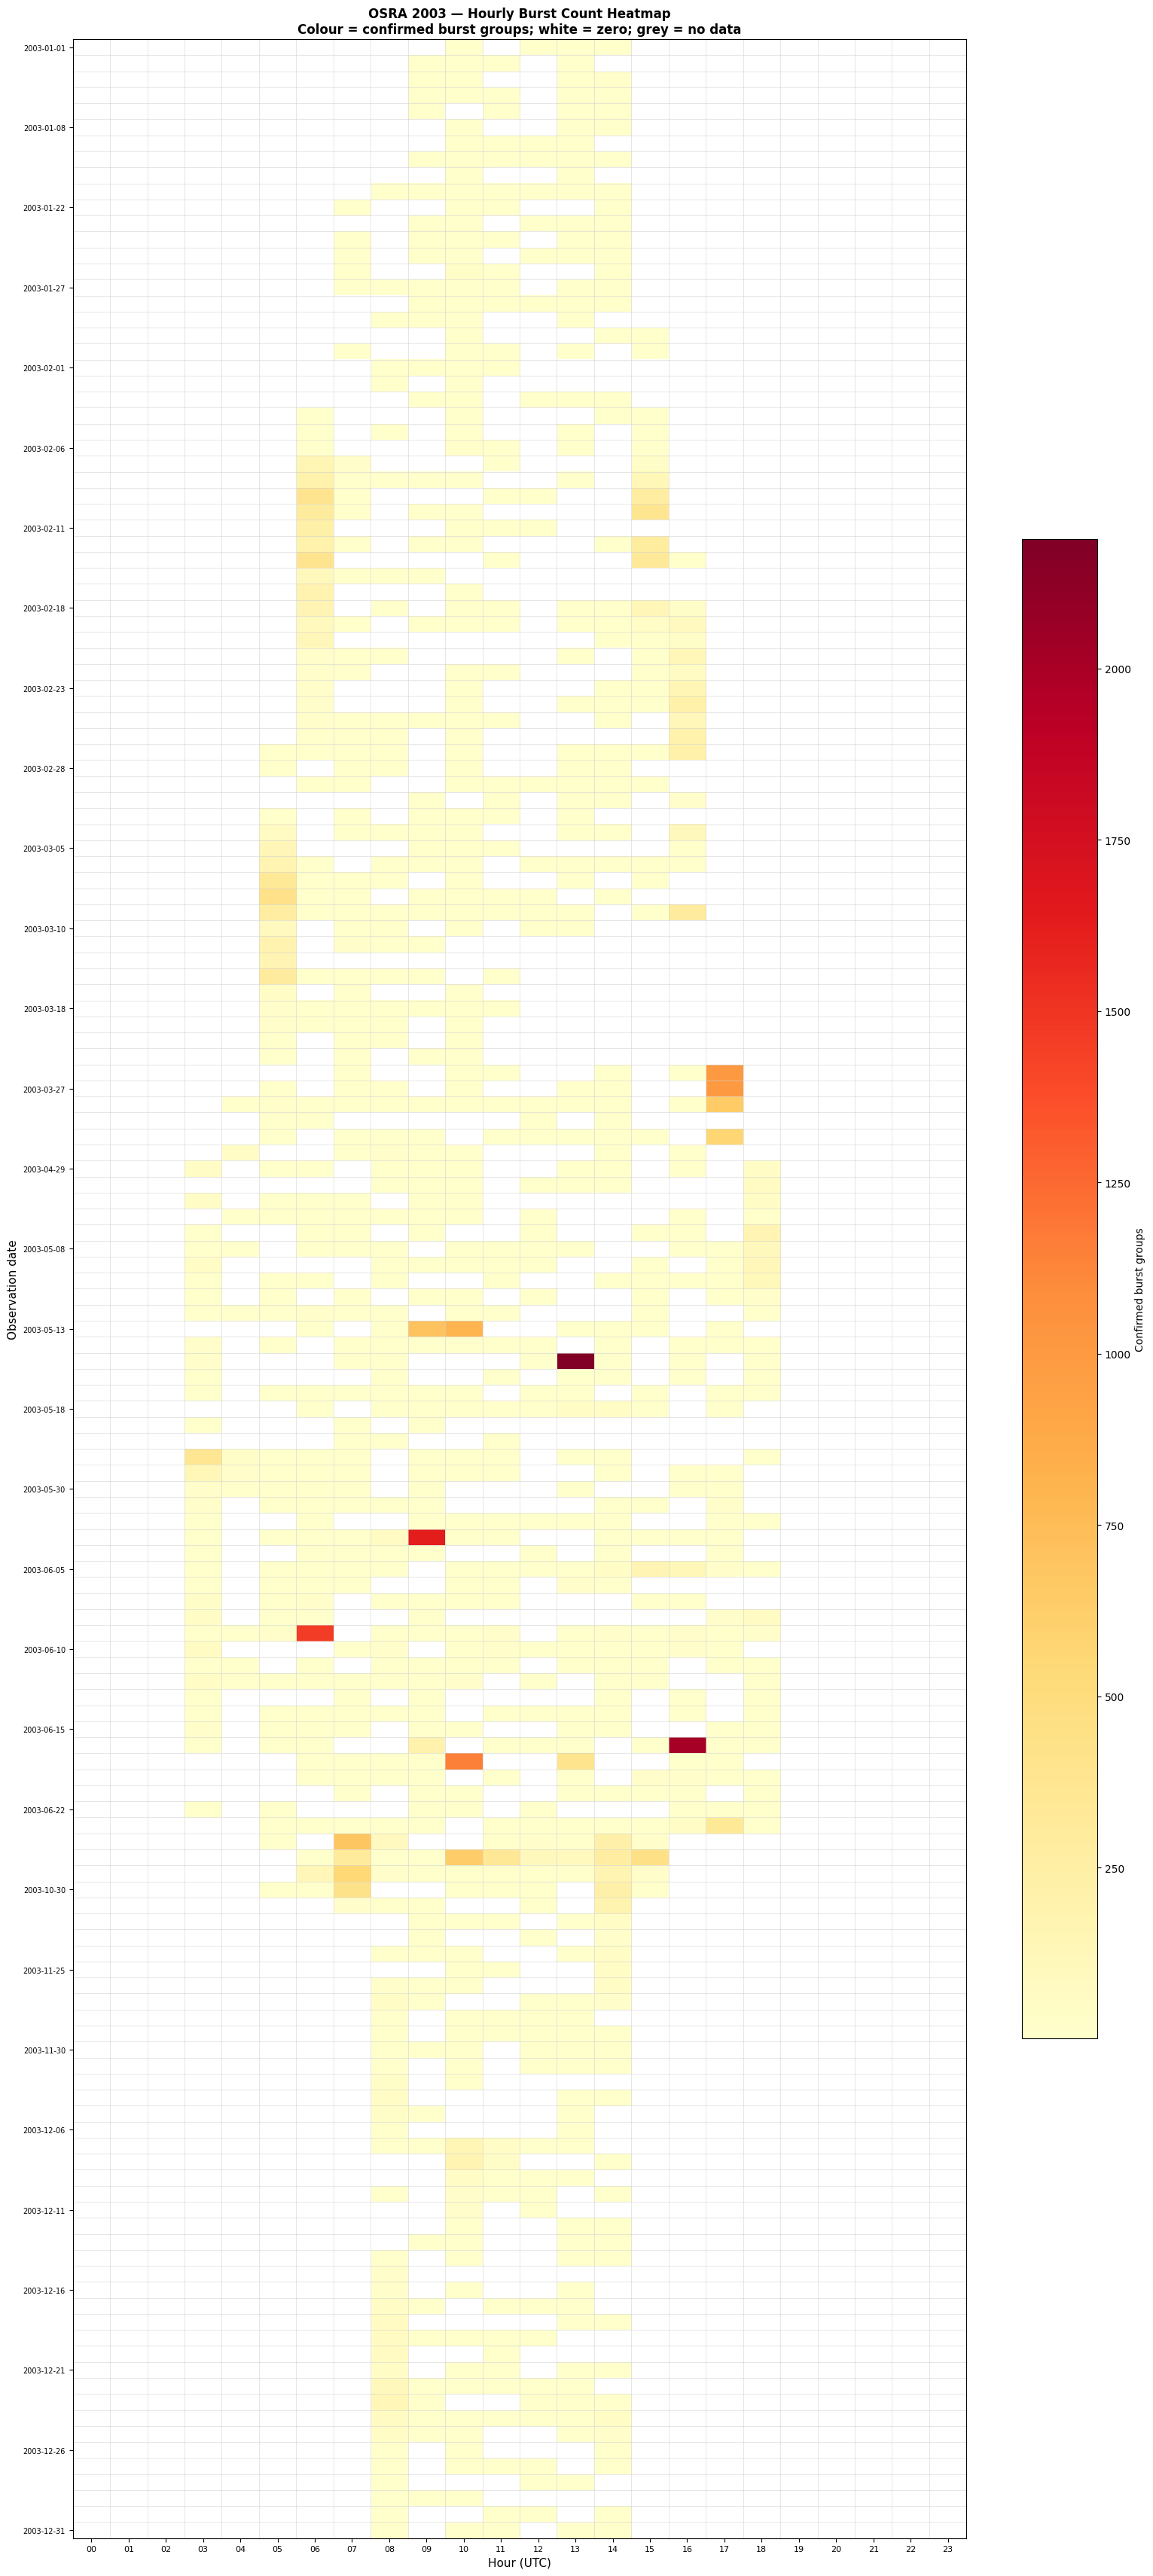

In [16]:
# ── Reload yearly CSV for the heatmap ─────────────────────────────────────────
# Use the on-disk CSV so the heatmap reflects the saved state, including any
# re-runs or back-filled days.
df_heat = pd.read_csv(yearly_csv_path, parse_dates=["date"])
df_heat = df_heat.sort_values("date").reset_index(drop=True)

# ── Build the (n_days × 24) burst matrix from the per-hour columns ────────────
# The CSV contains columns bursts_h00 … bursts_h23 written by append_daily_csv().
hour_cols    = [f"bursts_h{h:02d}" for h in range(24)]
burst_matrix = df_heat[hour_cols].values.astype(float)  # shape: (n_days, 24)

# Day labels for the y-axis
day_labels = df_heat["date"].dt.strftime("%Y-%m-%d").tolist()

# ── Plot heatmap ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, max(6, len(day_labels) * 0.22)))

# Replace zeros with NaN so that zero-burst cells render as a distinct
# background colour (white/light) rather than as the lowest colour in the map.
burst_matrix_plot = np.where(burst_matrix == 0, np.nan, burst_matrix)

im = ax.imshow(
    burst_matrix_plot,
    aspect='auto',
    cmap='YlOrRd',
    interpolation='none',
    origin='upper'
)

# Overlay grey grid to separate individual day rows
ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(day_labels), 1), minor=True)
ax.grid(which='minor', color='lightgrey', linewidth=0.4)
ax.tick_params(which='minor', bottom=False, left=False)

# Hour axis (x)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
ax.set_xlabel('Hour (UTC)', fontsize=11)

# Day axis (y) — label every 7th day to keep the axis readable
ytick_step = max(1, len(day_labels) // 30)
ax.set_yticks(range(0, len(day_labels), ytick_step))
ax.set_yticklabels(day_labels[::ytick_step], fontsize=7)
ax.set_ylabel('Observation date', fontsize=11)

ax.set_title(
    'OSRA 2003 — Hourly Burst Count Heatmap\n'
    'Colour = confirmed burst groups; white = zero; grey = no data',
    fontsize=12, fontweight='bold'
)

plt.colorbar(im, ax=ax, label='Confirmed burst groups', shrink=0.6)
plt.tight_layout()
plt.savefig(
    "/work1/okoro/type3detectosra/type3detectosra/outputs_Oneyear/solar_cycle/'OSRA 2003 — Hourly Burst Count Heatmap.png",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()

## 10  Top active days — detailed hourly breakdown

Display the per-hour confirmed burst counts for the 5 most active days  
as individual bar charts, mirroring the summary chart from `wholeday_bursts_daymask.ipynb`.

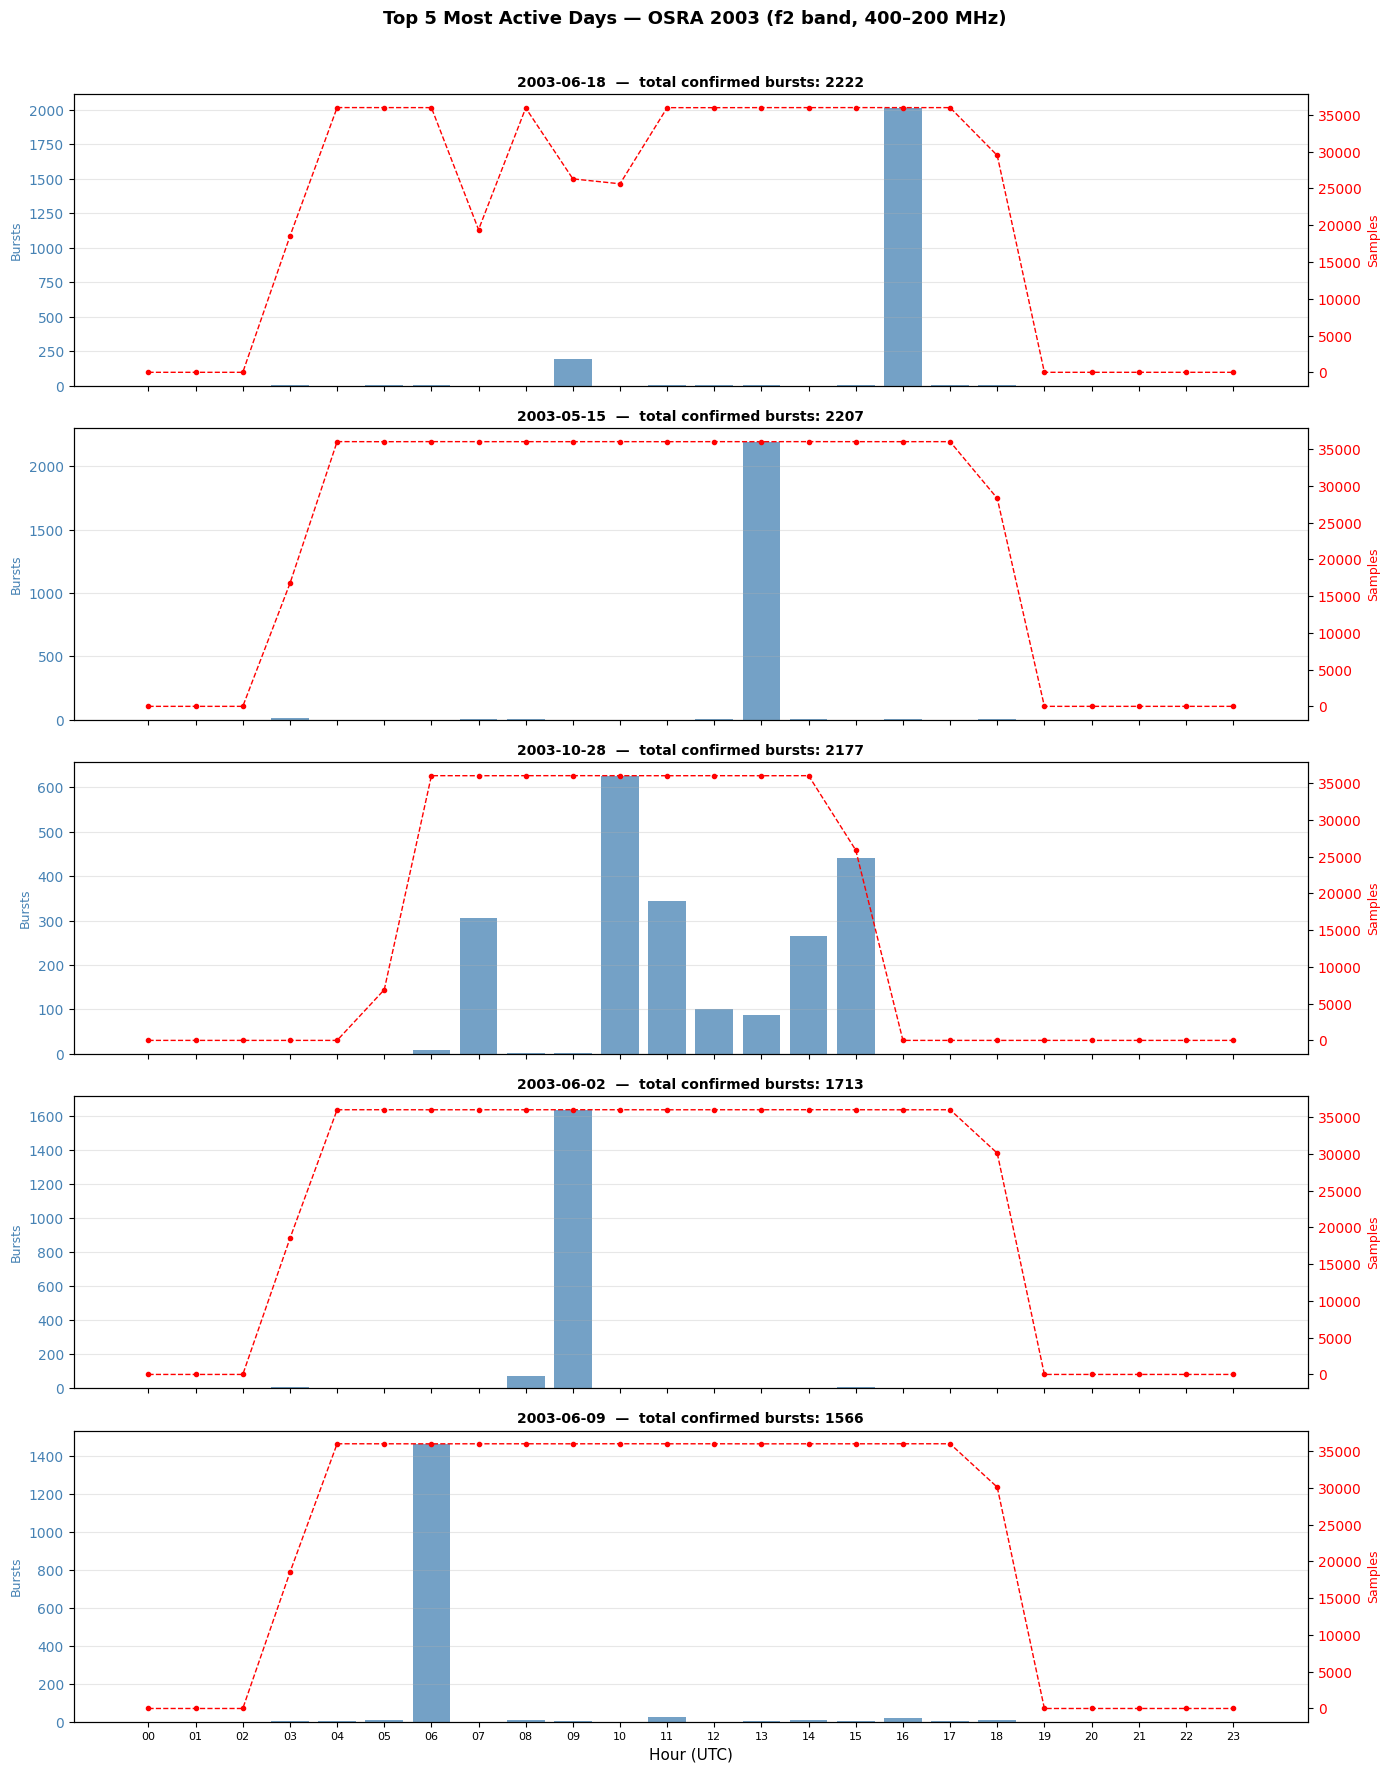

In [17]:
# ── Find the 5 most active days by total_bursts ───────────────────────────────
N_TOP = 5
top_days = df_heat.nlargest(N_TOP, "total_bursts")

fig, axes = plt.subplots(N_TOP, 1, figsize=(14, N_TOP * 3.5), sharex=True)

for ax, (_, row) in zip(axes, top_days.iterrows()):
    obs_date = row["date"].strftime("%Y-%m-%d")

    # Retrieve per-hour burst and sample counts from the CSV row
    hourly_bursts  = [row[f"bursts_h{h:02d}"]  for h in range(24)]
    hourly_samples = [row[f"samples_h{h:02d}"] for h in range(24)]

    ax2_twin = ax.twinx()

    # Burst bar chart (left axis)
    ax.bar(range(24), hourly_bursts, color='steelblue', alpha=0.75,
           label='Confirmed bursts')

    # Sample line chart (right axis — data quality indicator)
    ax2_twin.plot(range(24), hourly_samples, 'r--o', ms=3, lw=1.0,
                  label='Samples / hour')

    ax.set_ylabel('Bursts', color='steelblue', fontsize=9)
    ax2_twin.set_ylabel('Samples', color='red', fontsize=9)
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax2_twin.tick_params(axis='y', labelcolor='red')

    ax.set_title(
        f"{obs_date}  —  total confirmed bursts: {int(row['total_bursts'])}",
        fontsize=10, fontweight='bold'
    )
    ax.grid(axis='y', alpha=0.3)

# Shared x-axis formatting
axes[-1].set_xticks(range(24))
axes[-1].set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
axes[-1].set_xlabel('Hour (UTC)', fontsize=11)

fig.suptitle(
    f'Top {N_TOP} Most Active Days — OSRA 2003 (f2 band, 400–200 MHz)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    "/work1/okoro/type3detectosra/type3detectosra/outputs_Oneyear/solar_cycle/'OSRA 2003 — Hourly Burst Count Heatmap.png",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()